# Cube uniform-field: MMM/MSC H-matrix solver scaling

A uniformly-applied field on a **nonlinear soft-iron cube** meshed into an `N x N x N` grid of hexahedra (MSC, 6 surface-charge DOF/hex), swept over `N` to measure how the three Radia solver back-ends scale:

- **LU** (direct, dense) -- exact, O(N^3), the small-problem reference;
- **BiCGSTAB** (iterative, dense matvec) -- fast for medium problems;
- **HACApK** (H-matrix, ACA+) -- O(N log N) memory, the large-problem path.

The table below is read live from the committed benchmark JSON; the figures are the committed time/memory scaling curves for hexahedra and tetrahedra.

*Benchmark corpus (90 result JSON + scaling figures) kept at `validation_test/cube_uniform_field/`; this is the rendered showcase.*

In [1]:

import os, glob, json

REL = "../../validation_test/cube_uniform_field"

def load_runs(elem, solver):
    rows = []
    for fp in glob.glob(os.path.join(REL, elem, "nonlinear", solver, "*_results.json")):
        d = json.load(open(fp))
        rows.append(d)
    rows.sort(key=lambda d: d["n_elements"])
    return rows

print("Hexahedral cube, uniform applied field, nonlinear soft iron -- MSC 6-DOF/hex.")
print("Solver scaling: LU vs BiCGSTAB vs HACApK (H-matrix). Times in seconds.\n")
print(f"{'n_div':>5} {'n_elem':>7} {'ndof':>7} "
      f"{'t_LU':>9} {'t_BiCG':>9} {'t_HACApK':>9} "
      f"{'Hmat_MB':>8} {'dense_MB':>9} {'compress':>8}")
print("-" * 86)

lu  = {d["n_div"]: d for d in load_runs("hexahedron", "lu")}
bcg = {d["n_div"]: d for d in load_runs("hexahedron", "bicgstab")}
hac = {d["n_div"]: d for d in load_runs("hexahedron", "hacapk")}
for n in sorted(hac):
    h = hac[n]
    hm = h.get("hmatrix", {}) or {}
    def t(dct):
        return f"{dct[n]['t_solve']:9.2f}" if n in dct else f"{'--':>9}"
    print(f"{n:>5} {h['n_elements']:>7} {h['ndof']:>7} "
          f"{t(lu)} {t(bcg)} {h['t_solve']:9.2f} "
          f"{hm.get('memory_mb', float('nan')):8.1f} "
          f"{hm.get('dense_memory_mb', float('nan')):9.1f} "
          f"{hm.get('compression_ratio', float('nan')):8.3f}")

# Largest HACApK case headline
big = hac[max(hac)]
print(f"\nLargest HACApK case: N={big['n_div']}, {big['n_elements']} hex, ndof={big['ndof']}, "
      f"t_solve={big['t_solve']:.1f}s, peak_mem={big.get('peak_memory_mb', float('nan')):.0f} MB, "
      f"converged={big['converged']}.")


Hexahedral cube, uniform applied field, nonlinear soft iron -- MSC 6-DOF/hex.
Solver scaling: LU vs BiCGSTAB vs HACApK (H-matrix). Times in seconds.

n_div  n_elem    ndof      t_LU    t_BiCG  t_HACApK  Hmat_MB  dense_MB compress
--------------------------------------------------------------------------------------


    3      27     162      0.01      0.02      0.02      0.2       0.2    1.000
    4      64     384      0.02      0.02      0.02      1.1       1.1    1.000
    5     125     750      0.05      0.04      0.04      4.1       4.3    0.966
    6     216    1296      0.13      0.08      0.08     11.3      12.8    0.882
    7     343    2058      0.39      0.24      0.21     25.7      32.3    0.796
    8     512    3072      1.33      0.48      0.49     50.1      72.0    0.696
    9     729    4374      2.43      0.90      0.88     84.4     146.0    0.578
   10    1000    6000      8.92      1.71      1.52    135.4     274.7    0.493
   11    1331    7986     22.27      3.31      2.42    205.1     486.6    0.422
   12    1728   10368     54.26      5.41      4.12    311.1     820.1    0.379
   13    2197   13182    152.84      8.06      5.58    437.1    1325.7    0.330
   14    2744   16464    365.15     13.15      7.61    613.9    2068.0    0.297
   15    3375   20250    718.78     38.3

## Hexahedral scaling -- solve time and memory vs problem size

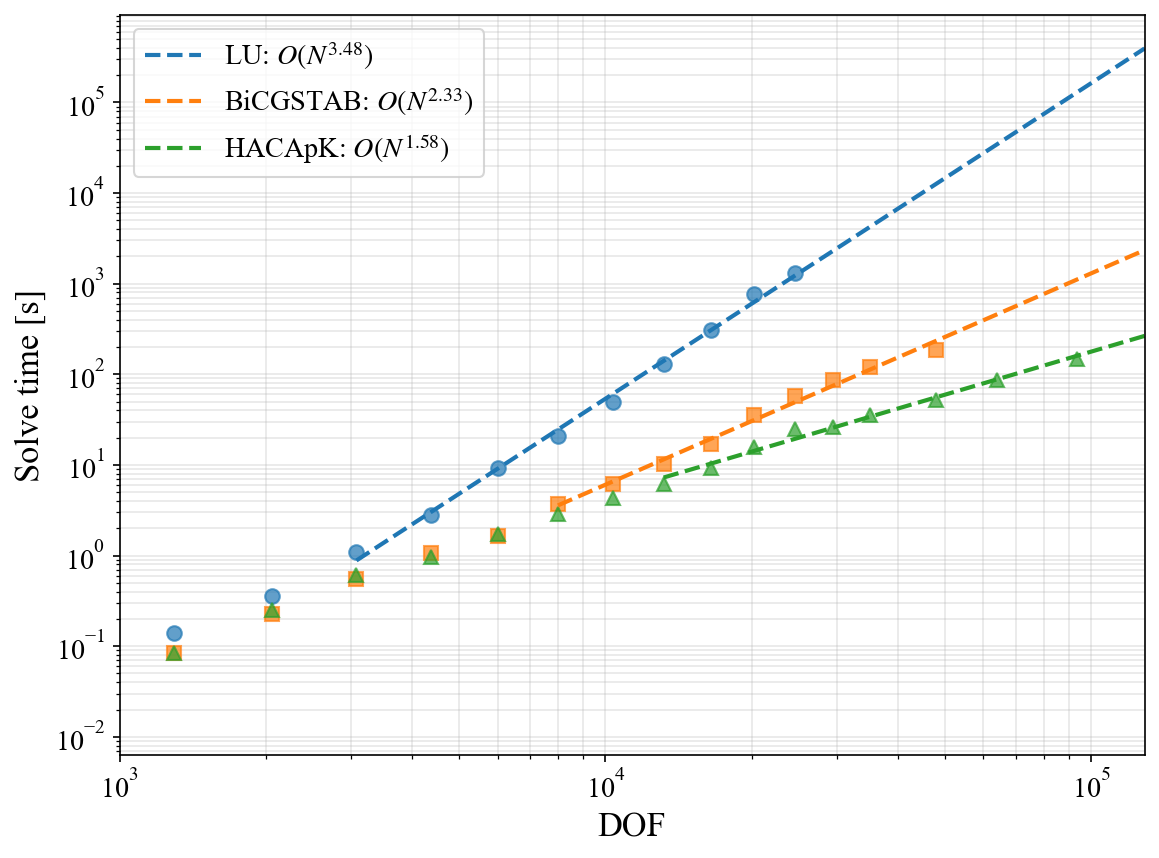

In [2]:
from IPython.display import Image, display
display(Image('../../validation_test/cube_uniform_field/hexahedron/scaling_time.png'))

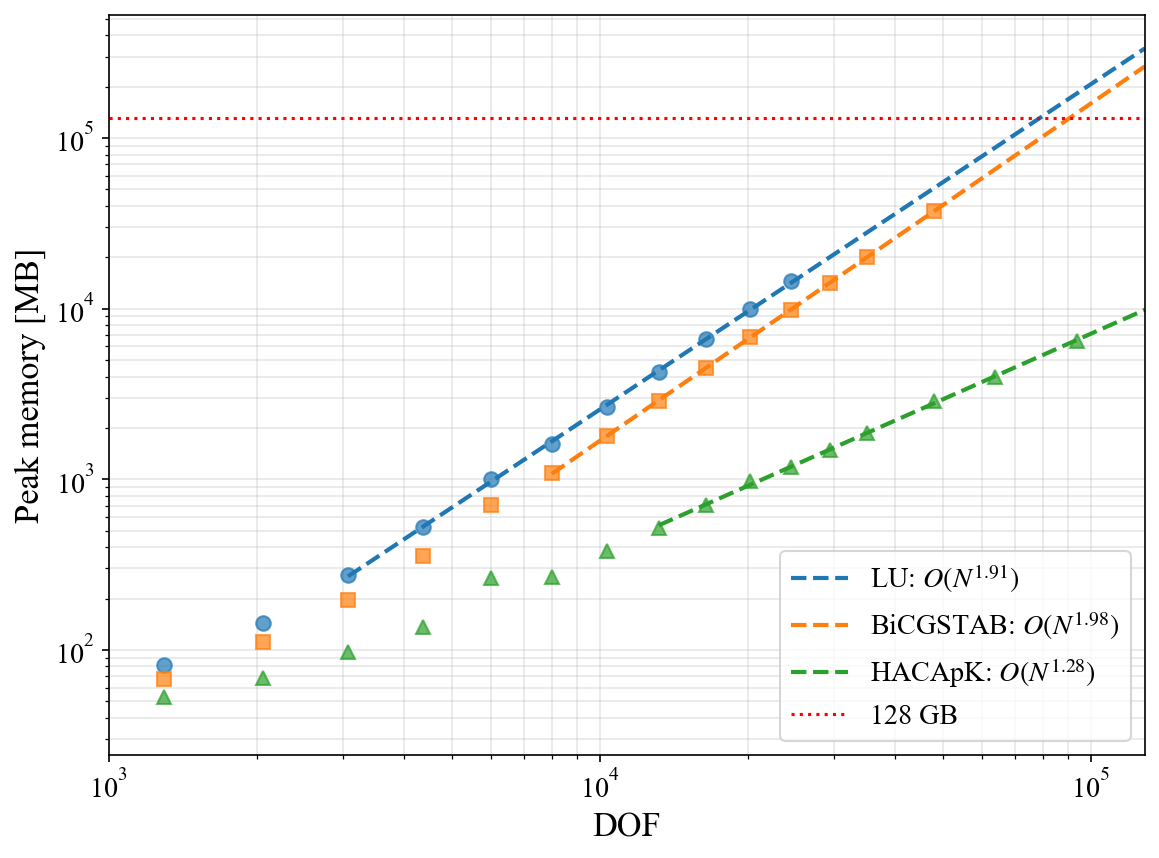

In [3]:
from IPython.display import Image, display
display(Image('../../validation_test/cube_uniform_field/hexahedron/scaling_memory.png'))

## Tetrahedral scaling (MMM 3-DOF/tet)

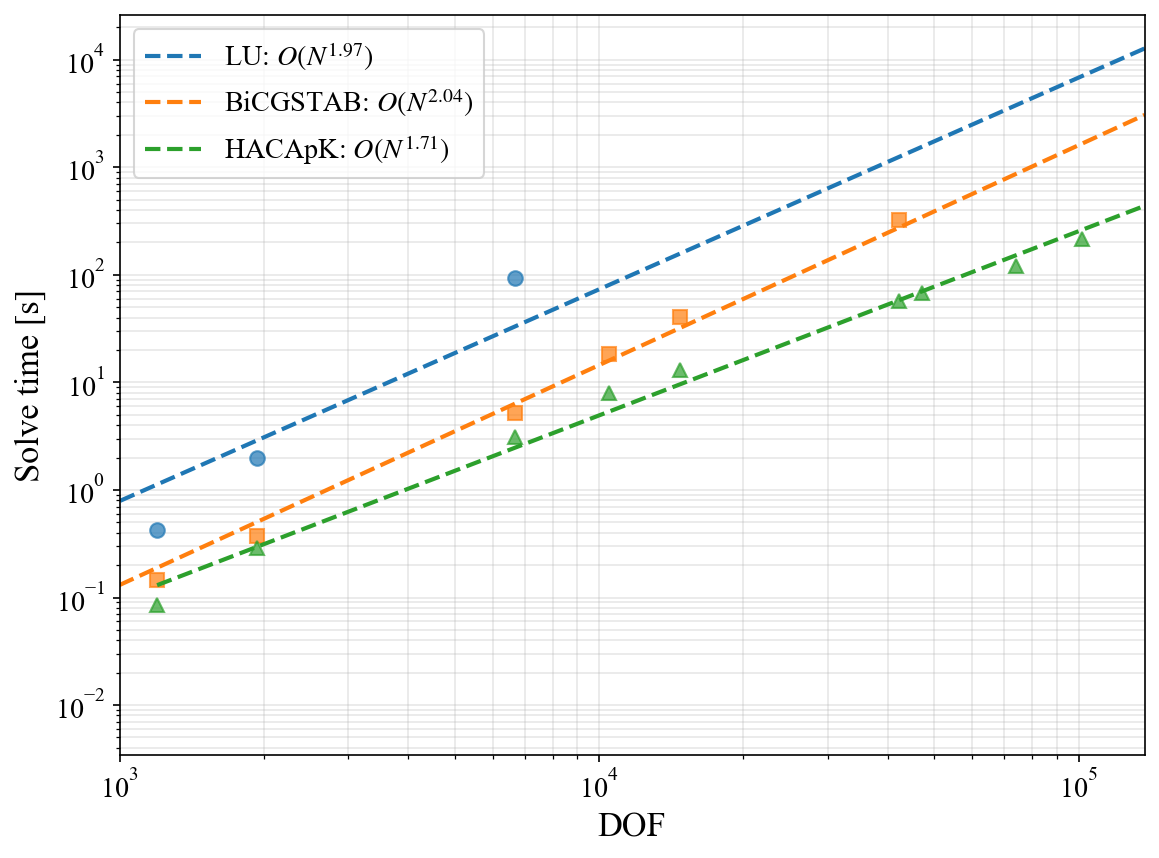

In [4]:
from IPython.display import Image, display
display(Image('../../validation_test/cube_uniform_field/tetrahedron/scaling_time.png'))

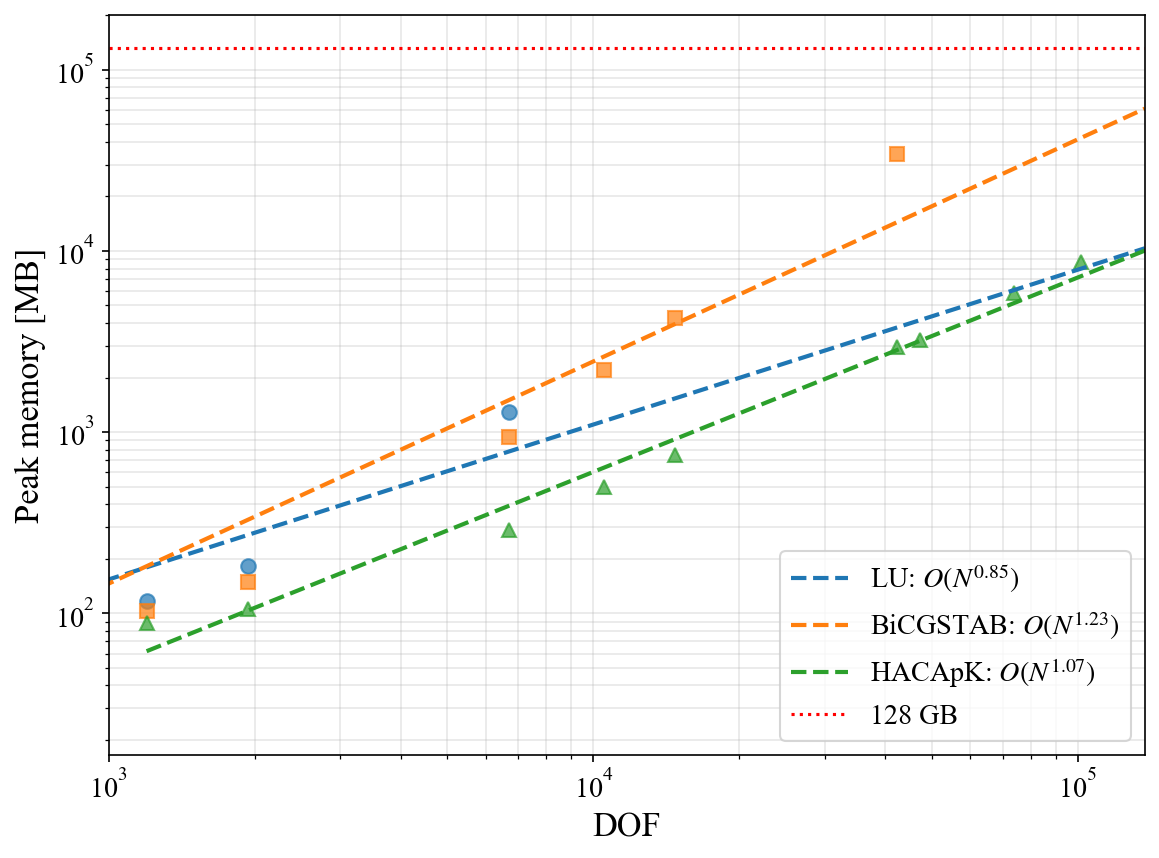

In [5]:
from IPython.display import Image, display
display(Image('../../validation_test/cube_uniform_field/tetrahedron/scaling_memory.png'))

**Takeaway:** HACApK's ACA+ compression turns the dense O(N^2) interaction matrix into O(N log N) storage (see the `compress` column = stored/dense), so it overtakes LU/BiCGSTAB in both time and memory as the element count grows -- the basis for using `method=2` (HACApK) on large MMM/MSC models. See `docs/HMATRIX_EVALUATION.md` for the full evaluation.